In [1]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
import matplotlib.patches as mpatches
import sys
sys.path.insert(1, 'code')
from help_funcs import *
pvcolor = (0.0, 0.4039, 0.7059)
sstcolor = (0.898,0.6314,0.0039)
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

0.11338284478214292 0.5193049126881979 1.833897091419043 0.19999999999999998
24.49699776225782 6.439281109382999 15.331477166523744 1.6286302931192624 24.49699776225782


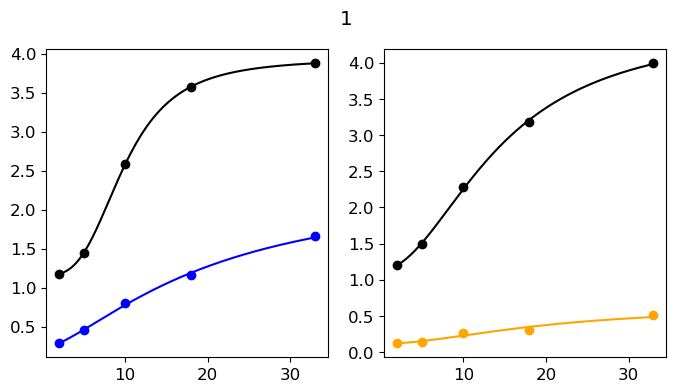

1


In [2]:
simname = 'base_a0.07_pf0.8'
workdir = 'work_dir'
contrasts = np.array([0.02, 0.05, 0.1, 0.18, 0.33])

slopes_cp, slopes_sp, slopes_cs, slopes_ss = [], [], [], []
binlen = 200  # ms time window from which spikes are counted
seedlist = np.array([1])  # RNG seeds used
nseeds = len(seedlist)

ctrl_pv_ave = np.zeros(5)
stim_pv_ave = np.zeros(5)
ctrl_sst_ave = np.zeros(5)
stim_sst_ave = np.zeros(5)

parameter_fits = []


for seed in seedlist:
    # contrasts = np.array([0.02, 0.05, 0.2, 0.3])
    # contrasts = np.array([0.02,  0.2])
    ctrl_pv_curve = [[] for i in range(4)]
    stim_pv_curve = [[] for i in range(4)]
    ctrl_sst_curve = [[] for i in range(4)]
    stim_sst_curve = [[] for i in range(4)]

    ctrl_pv_curve_e = [[] for i in range(4)]
    stim_pv_curve_e = [[] for i in range(4)]
    ctrl_sst_curve_e = [[] for i in range(4)]
    stim_sst_curve_e = [[] for i in range(4)]

    
    folder = '%s/%s/results_%s/'%(workdir,simname, seed)
    not_all_found=False
    for ci, cont in enumerate(contrasts):
        try:
            with open(folder + 'PV_%s_spikes.pickle'%cont, 'rb') as f:
                all_spikes = pickle.load(f)
            with open(folder + 'PV_%s_positions.pickle'%cont, 'rb') as f:
                all_positions = pickle.load(f)
        except FileNotFoundError:
            not_all_found = True
            break

        ctrlpv_E_mean, stimpv_E_mean, ctrlpv_E_err, stimpv_E_err = getStimRateMeans_v2(all_spikes[:8000], all_positions[:8000], binlen=binlen)
        ctrlpv_P_mean, stimpv_P_mean, ctrlpv_P_err, stimpv_P_err = getStimRateMeans_v2(all_spikes[8000:9000], all_positions[8000:9000], binlen=binlen)
        ctrlpv_S_mean, stimpv_S_mean, ctrlpv_S_err, stimpv_S_err = getStimRateMeans_v2(all_spikes[9000:10000], all_positions[9000:10000], binlen=binlen)
        ctrlpv_A_mean, stimpv_A_mean, ctrlpv_A_err, stimpv_A_err = getStimRateMeans_v2(all_spikes, all_positions, binlen=binlen)

        ctrl_pv_curve[0].append(ctrlpv_E_mean)
        ctrl_pv_curve[1].append(ctrlpv_P_mean)
        ctrl_pv_curve[2].append(ctrlpv_S_mean)
        ctrl_pv_curve[3].append(ctrlpv_A_mean)
        ctrl_pv_curve_e[0].append(ctrlpv_E_err)
        ctrl_pv_curve_e[1].append(ctrlpv_P_err)
        ctrl_pv_curve_e[2].append(ctrlpv_S_err)
        ctrl_pv_curve_e[3].append(ctrlpv_A_err)

        stim_pv_curve[0].append(stimpv_E_mean)
        stim_pv_curve[1].append(stimpv_P_mean)
        stim_pv_curve[2].append(stimpv_S_mean)
        stim_pv_curve[3].append(stimpv_A_mean)
        stim_pv_curve_e[0].append(stimpv_E_err)
        stim_pv_curve_e[1].append(stimpv_P_err)
        stim_pv_curve_e[2].append(stimpv_S_err)
        stim_pv_curve_e[3].append(stimpv_A_err)
        


        try:
            with open(folder + 'SST_%s_spikes.pickle'%cont, 'rb') as f:
                all_spikes = pickle.load(f)
            with open(folder + 'SST_%s_positions.pickle'%cont, 'rb') as f:
                all_positions = pickle.load(f)
        except FileNotFoundError:
            not_all_found = True
            break

        ctrlsst_E_mean, stimsst_E_mean, ctrlsst_E_err, stimsst_E_err = getStimRateMeans_v2(all_spikes[:8000], all_positions[:8000], binlen= binlen)
        ctrlsst_P_mean, stimsst_P_mean, ctrlsst_P_err, stimsst_P_err = getStimRateMeans_v2(all_spikes[8000:9000], all_positions[8000:9000], binlen= binlen)
        ctrlsst_S_mean, stimsst_S_mean, ctrlsst_S_err, stimsst_S_err = getStimRateMeans_v2(all_spikes[9000:10000], all_positions[9000:10000], binlen= binlen)
        ctrlsst_A_mean, stimsst_A_mean, ctrlsst_A_err, stimsst_A_err = getStimRateMeans_v2(all_spikes, all_positions, binlen= binlen)


        ctrl_sst_curve[0].append(ctrlsst_E_mean)
        ctrl_sst_curve[1].append(ctrlsst_P_mean)
        ctrl_sst_curve[2].append(ctrlsst_S_mean)
        ctrl_sst_curve[3].append(ctrlsst_A_mean)
        ctrl_sst_curve_e[0].append(ctrlsst_E_err)
        ctrl_sst_curve_e[1].append(ctrlsst_P_err)
        ctrl_sst_curve_e[2].append(ctrlsst_S_err)
        ctrl_sst_curve_e[3].append(ctrlsst_A_err)

        stim_sst_curve[0].append(stimsst_E_mean)
        stim_sst_curve[1].append(stimsst_P_mean)
        stim_sst_curve[2].append(stimsst_S_mean)
        stim_sst_curve[3].append(stimsst_A_mean)
        stim_sst_curve_e[0].append(stimsst_E_err)
        stim_sst_curve_e[1].append(stimsst_P_err)
        stim_sst_curve_e[2].append(stimsst_S_err)
        stim_sst_curve_e[3].append(stimsst_A_err)
    # contrasts = np.array([ 0.05, 0.1, 0.2, 0.3])
    
        ctrl_pv_ave[ci] += ctrlpv_E_mean
        stim_pv_ave[ci] += stimpv_E_mean
        ctrl_sst_ave[ci] += ctrlsst_E_mean
        stim_sst_ave[ci] += stimsst_E_mean
    
    if not_all_found:
        continue
#     continue
        
    params, cov = fit_naka_rushton(contrasts[:], ctrl_pv_curve[0][:], sigma=ctrl_pv_curve_e[0][:])
    m_cp, C_cp, n_cp, k_cp = params
    m_cp_err, C_cp_err, n_cp_err, k_cp_err = np.sqrt(np.diag(cov))
    slope_cp, _ = get_slope(m_cp, C_cp, n_cp, k_cp)
    
    params, cov = fit_naka_rushton(contrasts[:], stim_pv_curve[0][:], sigma=stim_pv_curve_e[0][:])
    m_sp, C_sp, n_sp, k_sp = params
    m_sp_err, C_sp_err, n_sp_err, k_sp_err = np.sqrt(np.diag(cov))
    slope_sp, _ = get_slope(m_sp, C_sp, n_sp, k_sp)
    
    params, cov = fit_naka_rushton(contrasts[:], ctrl_sst_curve[0][:], sigma=ctrl_sst_curve_e[0][:])
    m_cs, C_cs, n_cs, k_cs = params
    m_cs_err, C_cs_err, n_cs_err, k_cs_err = np.sqrt(np.diag(cov))
    slope_cs, _ = get_slope(m_cs, C_cs, n_cs, k_cs)
    
    params, cov = fit_naka_rushton(contrasts[:], stim_sst_curve[0][:], sigma=stim_sst_curve_e[0][:])
    m_ss, C_ss, n_ss, k_ss = params
    m_ss_err, C_ss_err, n_ss_err, k_ss_err = np.sqrt(np.diag(cov))
    slope_ss, _ = get_slope(m_ss, C_ss, n_ss, k_ss)
    
    
    slopes_cp.append(slope_cp)
    slopes_sp.append(slope_sp)
    slopes_cs.append(slope_cs)
    slopes_ss.append(slope_ss)
    
    print(m_ss, C_ss, n_ss, k_ss)
    parameter_fits.append([ m_cp, C_cp, n_cp, k_cp, m_sp, C_sp, n_sp, k_sp, m_cs, C_cs, n_cs, k_cs, m_ss, C_ss, n_ss, k_ss])
    
    print(slope_cp, slope_sp, slope_cs, slope_ss, np.max( [slope_cp, slope_sp, slope_cs, slope_ss] ) )
    
    cvals = np.arange(0.02,0.33,0.001)
    fig,axes = plt.subplots(1,2,figsize = (8,4))
    axes[0].scatter(contrasts*100, np.array(ctrl_pv_curve[0]), c='black')
    axes[0].scatter(contrasts*100, np.array(stim_pv_curve[0]), c='blue')
    yvals = naka_rushton(cvals, m_cp, C_cp, n_cp, k_cp)
    axes[0].plot(cvals*100, yvals, c='black')
    yvals = naka_rushton(cvals, m_sp, C_sp, n_sp, k_sp)
    axes[0].plot(cvals*100, yvals, c='blue')
    
    axes[1].scatter(contrasts*100, np.array(ctrl_sst_curve[0]), c='black')
    axes[1].scatter(contrasts*100, np.array(stim_sst_curve[0]), c='orange')
    yvals = naka_rushton(cvals, m_cs, C_cs, n_cs, k_cs)
    axes[1].plot(cvals*100, yvals, c='black')
    yvals = naka_rushton(cvals, m_ss, C_ss, n_ss, k_ss)
    axes[1].plot(cvals*100, yvals, c='orange')
    plt.suptitle(seed)
    plt.show()
    
    print(seed)
    
ctrl_pv_ave = ctrl_pv_ave/nseeds
stim_pv_ave = stim_pv_ave/nseeds
ctrl_sst_ave = ctrl_sst_ave/nseeds
stim_sst_ave = stim_sst_ave/nseeds

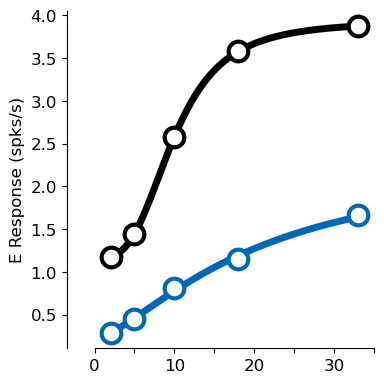

In [3]:
import seaborn as sns
fig, ax = plt.subplots(figsize = (4,4))
cvals = np.arange(0.02,0.33,0.001)
ctrlave = np.zeros(len(cvals))
stimave = np.zeros(len(cvals))


for ti in range(nseeds):
    m_cp, C_cp, n_cp, k_cp, m_sp, C_sp, n_sp, k_sp, m_cs, C_cs, n_cs, k_cs, m_ss, C_ss, n_ss, k_ss = parameter_fits[ti]

    
    yvals = naka_rushton(cvals, m_cp, C_cp, n_cp, k_cp)

    ax.plot(cvals,yvals, c= 'black', alpha=0.1)
    
    ctrlave += yvals
    
    cvals = np.arange(0.02,0.33,0.001)
    yvals = naka_rushton(cvals, m_sp, C_sp, n_sp, k_sp)
    stimave += yvals

    ax.plot(cvals,yvals, c= pvcolor, alpha=0.1)

    

ax.plot(cvals,stimave/nseeds, c=pvcolor, lw=5)
ax.plot(cvals,ctrlave/nseeds, c='black', lw=5)

ax.set_ylabel('E Response (spks/s)')
# ax.set_yticks([60,80,100,120])
# ax.set_ylim(60,130)

ax.scatter(contrasts, ctrl_pv_ave, edgecolor='black', linewidth=3, s=200, facecolor = 'white', zorder=10)
ax.scatter(contrasts, stim_pv_ave, edgecolor=pvcolor, linewidth=3, s=200, facecolor = 'white', zorder=10)

ax.set_xlim(0.02,0.33)
ax.set_xticks([i*0.05 for i in range(8)])
ax.set_xticklabels([0,'',10,'',20,'',30,''])
sns.despine(offset={'left':20}, trim=False)

plt.tight_layout()

plt.show()

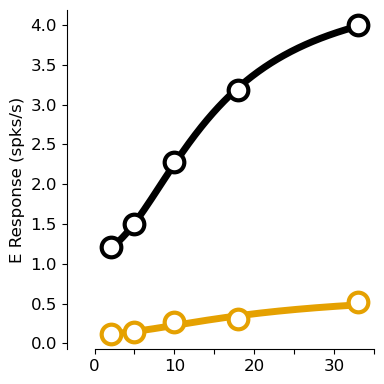

In [4]:
import seaborn as sns
fig, ax = plt.subplots(figsize = (4,4))
cvals = np.arange(0.02,0.33,0.001)
ctrlave = np.zeros(len(cvals))
stimave = np.zeros(len(cvals))

for ti in range(nseeds):
    m_cp, C_cp, n_cp, k_cp, m_sp, C_sp, n_sp, k_sp, m_cs, C_cs, n_cs, k_cs, m_ss, C_ss, n_ss, k_ss = parameter_fits[ti]

    
    yvals = naka_rushton(cvals, m_cs, C_cs, n_cs, k_cs)

    ax.plot(cvals,yvals, c= 'black', alpha=0.1)
    
    ctrlave += yvals
    
    cvals = np.arange(0.02,0.33,0.001)
    yvals = naka_rushton(cvals, m_ss, C_ss, n_ss, k_ss)
    stimave += yvals

    ax.plot(cvals,yvals, c= sstcolor, alpha=0.1)

    
ax.plot(cvals,stimave/nseeds, c=sstcolor, lw=5)
ax.plot(cvals,ctrlave/nseeds, c='black', lw=5)
ax.scatter(contrasts, ctrl_sst_ave, edgecolor='black', linewidth=3, s=200, facecolor = 'white', zorder=10)
ax.scatter(contrasts, stim_sst_ave, edgecolor=sstcolor, linewidth=3, s=200, facecolor = 'white', zorder=10)

ax.set_ylabel('E Response (spks/s)')

ax.set_xlim(0.02,0.33)
ax.set_xticks([i*0.05 for i in range(8)])
ax.set_xticklabels([0,'',10,'',20,'',30,''])
sns.despine(offset={'left':20}, trim=False)
plt.tight_layout()

plt.show()